# 🌊 Machine Learning Pipeline Architecture

ไปป์ไลน์นี้ถูกออกแบบมาในลักษณะ **Two-stage Model** (Classification ตามด้วย Regression) เพื่อทำนายการฟอกขาว (Bleaching) โดยมีขั้นตอนการทำงานดังนี้:

## 1. ข้อมูลนำเข้า (Input Data)
* **Features:** ข้อมูลเริ่มต้น 37 ตัวแปร 
* **ขนาดข้อมูล (Data Size):** 1k – 10k แถว (Rows)

## 2. การคัดเลือกตัวแปร (Feature Selection)
* ใช้ **SHAP importance** ในการประเมินความสำคัญของตัวแปร
* เลือกใช้ตัวแปรแกนหลัก 7 ตัว (Core) ร่วมกับตัวแปรที่ผ่านการทำ Feature Engineering

---

## 3. ขั้นตอนการทำโมเดล (Modeling Stages)
โมเดลทั้งสองด่านใช้เทคนิค **Stacking Ensemble** โดยใช้โมเดลพื้นฐาน (Base Models) 3 ตัว ได้แก่ Random Forest (RF), LightGBM (LGB) และ XGBoost (XGB)

### Stage 1: Classification (การจำแนกประเภท)
* **เป้าหมาย:** ทำนายว่ามีการฟอกขาวหรือไม่ (Zero vs Non-zero bleaching)
* **Stacking:** นำผลจาก Base Models ส่งต่อไปยัง **Meta-learner (LR - Logistic Regression)**

### Stage 2: Regression (การวิเคราะห์การถดถอย)
* **เป้าหมาย:** ทำนายระดับความรุนแรงของการฟอกขาว (Predict severity 1–100%)
* **Stacking:** นำผลจาก Base Models ส่งต่อไปยัง **Meta-learner (Ridge Regression)**

---

## 4. เงื่อนไขผลลัพธ์ (Decision Logic)
ผลลัพธ์จาก Stage 1 จะถูกนำมาใช้เป็นเงื่อนไขตัดสินใจ (**Zero?**):
* **Yes (ใช่):** หากไม่มีการฟอกขาว ระดับความรุนแรง (Severity) จะถูกกำหนดให้เป็น **0%**
* **No (ไม่ใช่):** หากมีการฟอกขาว จะใช้ผลลัพธ์จาก Stage 2 เพื่อระบุระดับความรุนแรงที่ **1-100%**

---

## 5. การประเมินผล (Evaluation)
ประเมินผลโมเดลด้วยวิธี **Spatial block CV** (Cross-Validation เชิงพื้นที่) เพื่อป้องกัน Data Leakage
* **มาตรวัด Stage 1:** F1-score และ AUC
* **มาตรวัด Stage 2:** RMSE, MAE และ R²

## 6. การตีความโมเดล (Interpretation)
* วิเคราะห์และตีความผลลัพธ์ด้วย **SHAP**
* เพื่อดูความสำคัญของตัวแปร (Feature importance) และรูปแบบเชิงพื้นที่ (Spatial patterns)

----------------------------------------------

##

# 📄 [ Two-stage technique for using machine learning ]

**Conference:** Asia-Pacific Signal and Information Processing Association Annual Summit and Conference (APSIPA ASC 2026)  
**Authors:** [ นายณฐนนท์ เขื่อนทา ]  
**Affiliation:** [ มหาวิทยาลัยเกษตรศาสตร์ คณะวิศวกรรมศาสตร์ สาขาวิศวกรรมคอมพิวเตอร์ ]  

##

##

In [339]:
# loading packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import shap

In [340]:
# machine learning regression
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import PolynomialFeatures , MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, BayesianRidge 
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  , mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.utils import shuffle
from sklearn.cluster import KMeans

from xgboost import XGBRegressor
import lightgbm as lgb

In [341]:
# Machine Leraning Classify
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

In [342]:
#=========================================================
#  Load dataset and checking nan
#=========================================================

df_original = pd.read_csv("C:\\Github\\Coral_Bleaching_Predictor\\Data\\dataset.csv" , na_values=['nd']) # old data
print(f"total number of rows and columns in the dataset: {len(df_original.columns) + 1} columns, {len(df_original) + 1} rows")


# Grouping years into decodes
def Grouping_date_to_year(df):
    #Changing date to year
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['Year'] = df['Date'].dt.year # New columns with only year 
    
    year_counts = df.groupby(['Year']).size()
    print(year_counts)
    

    return df

df_Grouping_year = Grouping_date_to_year(df_original)

# Check NAN Data and by what percentage
def nan_check(data):
    total = data.isnull().sum().sort_values(ascending=False)
    percent_1 = data.isnull().sum()/data.isnull().count()*100
    percent_2 = (np.round(percent_1, 1)).sort_values(ascending=False)
    missing_data = pd.concat([total, percent_2], axis=1, keys=['Total', '%'])
    return missing_data

Missing  = nan_check(df_Grouping_year)
Missing

total number of rows and columns in the dataset: 49 columns, 9666 rows
Year
1998      5
2000      2
2001      3
2002     63
2003    599
2004    731
2005    700
2006    850
2007    643
2008    692
2009    721
2010    538
2011    533
2012    563
2013    626
2014    600
2015    615
2016    619
2017    562
dtype: int64


,Total,%
City_Town_3,8728,90.3
City_Town_2,4943,51.1
City_Town,437,4.5
State_Island_Province,36,0.4
SSTA_Minimum,12,0.1
SSTA_FrequencyMax,5,0.1
SSTA_Standard_Deviation,5,0.1
TSA_Maximum,5,0.1
SSTA_Maximum,5,0.1
SSTA_Frequency,5,0.1


In [343]:
df_original[['Realm']].value_counts()

Realm                     
Central Indo-Pacific          5420
Tropical Atlantic             1915
Western Indo-Pacific          1264
Eastern Indo-Pacific           670
Temperate Australasia          266
Temperate Northern Pacific     113
Tropical Eastern Pacific        17
Name: count, dtype: int64

In [344]:
df_original[df_original['Realm'] == 'Tropical Eastern Pacific'].describe()

,ID,Latitude_Degrees,Longitude_Degrees,Date,Date2,Depth,Average_Bleaching,ClimSST,Temperature_Kelvin,Temperature_Mean,...,TSA_Mean,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Year
count,17.000000,17.000000,17.000000,17,1.700000e+01,17.000000,17.000000,17.000000,17.000000,17.000000,...,17.000000,17.000000,17.000000,17.000000,17.000000,17.0,17.000000,17.000000,17.000000,17.000000
mean,5476.117647,8.845163,-83.984342,2009-11-11 15:31:45.882352896,2.009524e+07,8.435294,10.529412,302.104118,301.918235,301.495882,...,-1.225294,1.058824,1.765294,8.647059,0.294118,0.0,0.981765,8.473529,0.322941,2009.470588
min,5468.000000,8.704694,-85.799694,2009-02-04 00:00:00,2.009020e+07,4.000000,0.000000,301.020000,300.420000,300.190000,...,-1.240000,0.000000,1.250000,6.000000,0.000000,0.0,0.730000,4.880000,0.210000,2009.000000
25%,5472.000000,8.715889,-83.873889,2009-06-21 00:00:00,2.009062e+07,7.000000,0.500000,301.550000,301.140000,301.580000,...,-1.240000,0.000000,1.580000,8.000000,0.000000,0.0,0.850000,8.070000,0.240000,2009.000000
50%,5476.000000,8.715889,-83.869528,2009-12-14 00:00:00,2.009121e+07,8.800000,6.250000,301.960000,301.770000,301.580000,...,-1.240000,0.000000,1.580000,8.000000,0.000000,0.0,0.850000,8.070000,0.240000,2009.000000
75%,5480.000000,8.717111,-83.869528,2010-02-22 00:00:00,2.010022e+07,10.000000,15.000000,302.730000,302.830000,301.580000,...,-1.240000,1.000000,1.580000,8.000000,0.000000,0.0,0.850000,8.070000,0.240000,2010.000000
max,5486.000000,10.930750,-83.866417,2010-06-15 00:00:00,2.010062e+07,11.700000,42.500000,302.830000,303.690000,301.580000,...,-1.010000,14.000000,5.060000,21.000000,5.000000,0.0,3.210000,18.120000,1.680000,2010.000000
std,5.266431,0.537456,0.467815,NaN,5.012961e+03,1.968166,13.082336,0.673462,1.007951,0.336657,...,0.055691,3.362859,0.852776,3.219883,1.212678,0.0,0.574937,2.603008,0.349781,0.514496


In [345]:
#=================================================
# Function analysis variable for Cleaning data
#=================================================
def Columns_percent_missing(df,df_dtype, col):
    
    count_less = 0
    count_more = 0
    Index_more = []
    Index_less = []
    for_drop = []
    type_object = []
    type_number = []
    for idx, value in df[col].items():
        if value >= 0.4:
            count_more += 1
            Index_more.append(idx)
            for_drop.append(idx)
        elif value < 0.4:
            count_less += 1
            Index_less.append(idx)
            
    for i in df_dtype.columns:
        if df_dtype[i].dtype == 'object':
            type_object.append(i)
        else:
            type_number.append(i)

    print("\n")
    print(f"more than 0.4% : {count_more}")
    print(f"less than 0.4% : {count_less}")
    print(f"Name_of_moreNAN : {len(Index_more)} attribuue : {Index_more}")
    print(f"Name_of_lessNAN : {len(Index_less)} attribuue : {Index_less}")
    print(f"for_drop : {len(for_drop)} attribuue : {for_drop}")
    print(f"object type : {len(type_object)} attribue : {type_object}")
    print(f"number type : {len(type_number)} attribue : {type_number}")

    return for_drop , type_object
    
columns_drop, col_object = Columns_percent_missing(Missing, df_original, '%')
print("="*80)
print(">>>>>>>  Missing values more than 0.4% : Delete <<<<<<<<")
print("="*80)



more than 0.4% : 4
less than 0.4% : 45
Name_of_moreNAN : 4 attribuue : ['City_Town_3', 'City_Town_2', 'City_Town', 'State_Island_Province']
Name_of_lessNAN : 45 attribuue : ['SSTA_Minimum', 'SSTA_FrequencyMax', 'SSTA_Standard_Deviation', 'TSA_Maximum', 'SSTA_Maximum', 'SSTA_Frequency', 'SSTA_Frequency_Standard_Deviation', 'SSTA_Mean', 'SSTA_FrequencyMean', 'Temperature_Kelvin_Standard_Deviation', 'SSTA_DHW', 'SSTA_DHW_Standard_Deviation', 'SSTA_DHWMax', 'SSTA_DHWMean', 'TSA', 'SSTA', 'Temperature_Minimum', 'Temperature_Maximum', 'TSA_Minimum', 'Temperature_Mean', 'Temperature_Kelvin', 'TSA_Mean', 'TSA_Frequency', 'TSA_Frequency_Standard_Deviation', 'TSA_FrequencyMax', 'TSA_FrequencyMean', 'TSA_DHW', 'TSA_DHW_Standard_Deviation', 'TSA_DHWMax', 'TSA_DHWMean', 'TSA_Standard_Deviation', 'Windspeed', 'ClimSST', 'ID', 'Latitude_Degrees', 'Average_Bleaching', 'Depth', 'Date2', 'Date', 'Country_Name', 'Ecoregion', 'Realm', 'Ocean', 'Longitude_Degrees', 'Year']
for_drop : 4 attribuue : ['City

In [346]:
#=========================================
# Cleaning data
#=========================================
def Clean_data_paper(df, col_object, col_dont_need):
    
    # using data from 2003 to 2020
    df = df[df['Year'] > 2002]

    # Taking only SSTA > 0
    df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
    df = df[df['SSTA'] > 0] # เลือกเฉพาะคที่มีค่า SSTA มากกว่า 0 เเละ NaN จะถูกละทิ้งไปโดยอัตโนมัติ
    
    df_object = df.drop(columns=col_object) # ลบคอลัมน์ที่เป็น Object ออกเเละค่าที่ไม่จำเป็นออกไป
    df_dont_need = df_object.drop(columns=col_dont_need) # ลบคอลัมน์ที่ไม่จำเป็นออกไป

    df = df_dont_need.rename(columns={"Depth": "Depth_m", "Average_Bleaching": "Percent_Bleaching"}) # เปลี่ยนชื่อคอลัมน์ให้สั้นลง เเละเจข้าใจง่ายขึ้น

    #Transforming column datatypes
    df['ClimSST'] = pd.to_numeric(df['ClimSST'],errors='coerce')
    df['Percent_Bleaching'] = pd.to_numeric(df['Percent_Bleaching'],errors='coerce')
    
    return df

col_dont_need = ['ID', 'Date', 'Date2', 'SSTA_Mean']
df_Clean_already = Clean_data_paper(df_Grouping_year, col_object, col_dont_need)
df_Clean_already = df_Clean_already.fillna(method='ffill')
print("="*200)
print(f"{col_object} >>>>> {col_dont_need} : {len(col_object) + len(col_dont_need)} >>>>>>>> {len(df_original.columns) - len(col_object) - len(col_dont_need)}")
print(f"total number of rows and columns in the dataset: {len(df_Clean_already.columns)} columns, {len(df_Clean_already)} rows")
print("มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี")
print("="*200)

['Ocean', 'Realm', 'Ecoregion', 'Country_Name', 'State_Island_Province', 'City_Town', 'City_Town_2', 'City_Town_3'] >>>>> ['ID', 'Date', 'Date2', 'SSTA_Mean'] : 12 >>>>>>>> 37
total number of rows and columns in the dataset: 37 columns, 6112 rows
มีการเพิ่มคอลัมน์ Year ขึ้นมาเพื่อนำมาใช้ในการจัดกลุ่มข้อมูลตามปี


C:\Users\superuser\AppData\Local\Temp\ipykernel_25608\4233094419.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SSTA'] = pd.to_numeric(df['SSTA'], errors='coerce') # แปลง ค่าของ SSTA เป็นตัวเลข เเละจัดการกับค่าที่ไม่สามารถเเปลงได้ด้วยการใช้ 'coerce' ซึ่งจะทำให้ค่าที่แปลงไม่ได้กลายเป็น NaN
C:\Users\superuser\AppData\Local\Temp\ipykernel_25608\4233094419.py:26: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_Clean_already = df_Clean_already.fillna(method='ffill')


## ***ตัวแปรที่เก็บ data เเละพร้อมใช้งานสำหรับการนำไปวิเคราะห์ df_Clean_already***

##

##

### - **Exploratory Data Analysis**

In [347]:
#===============================================
# Total Function 
#===============================================

def Plotting_feature_target(df,col_feature, col_target='Percent_Bleaching'):
    
    X = df[col_feature]
    y = df[col_target]
    
    plt.figure(figsize=(6,4))
    plt.scatter(X, y, color='white', edgecolor='black', alpha=0.7)
    plt.xlabel(col_feature)
    plt.ylabel(col_target)
    plt.title(f'{col_feature} vs {col_target}')
    plt.show()

In [348]:
df_exploratory = df_Clean_already.copy()

In [349]:
# 1. สร้างคอลัมน์ 'Bin' เพื่อช่วยในการแบ่ง (Stratification)
# แบ่งเป็น 0 (ไม่ฟอก) กับ 1 (ฟอกขาว)
df_exploratory['Classify'] = (df_exploratory['Percent_Bleaching'] >= 1).astype(int)
print(df_exploratory[['Classify']].value_counts())
print('='*40)
print(f"Original feature : {len(df_Clean_already.columns)} ---> become {len(df_exploratory.columns)}")

Classify
0           4513
1           1599
Name: count, dtype: int64
Original feature : 37 ---> become 38


In [350]:
df_exploratory[['SSTA', 'SSTA_DHW', 'Temperature_Kelvin', 'TSA_DHW',  'Temperature_Maximum', 'Depth_m', 'Percent_Bleaching']].describe()

,SSTA,SSTA_DHW,Temperature_Kelvin,TSA_DHW,Temperature_Maximum,Depth_m,Percent_Bleaching
count,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000,6112.000000
mean,0.712972,3.153033,301.619961,1.060179,305.107758,6.471188,2.795220
std,0.547437,4.082572,2.091429,2.778678,1.456720,3.467763,9.634113
min,0.002500,0.000000,292.030000,0.000000,301.430000,0.100000,0.000000
25%,0.300000,0.000000,300.550000,0.000000,304.330000,4.000000,0.000000
50%,0.600000,1.918750,302.110000,0.000000,305.171667,6.000000,0.000000
75%,1.000000,4.602500,303.060000,1.120000,305.820000,10.000000,1.000000
max,4.610000,38.450000,306.800000,37.680000,313.140000,23.000000,100.000000


In [351]:
#===============================
# >= 1 is Bleaching
#===============================
Bleaching = df_exploratory[df_exploratory['Classify'] == 1]

In [352]:
def Bleaching_Alert_Levels(df, DHW):

    Group_1_DHW_4 = []
    Group_4_DHW_8 = []
    Group_8_DHW_12 = []
    Group_since12 = []

    for idx, value in df[DHW].items():

        row = df.loc[idx]

        if 1.0 >= value < 4.0:
            Group_1_DHW_4.append(row)

        elif 4.0 <= value < 8.0:
            Group_4_DHW_8.append(row)

        elif 8.0 <= value < 12.0:
            Group_8_DHW_12.append(row)

        elif value >= 12.0:
            Group_since12.append(row)


    return (
        pd.DataFrame(Group_1_DHW_4),
        pd.DataFrame(Group_4_DHW_8),
        pd.DataFrame(Group_8_DHW_12),
        pd.DataFrame(Group_since12),
    )


Group_1_DHW_4, Group_4_DHW_8, Group_8_DHW_12, Group_since12 = Bleaching_Alert_Levels(df_exploratory, 'SSTA_DHW')

In [353]:
print(f"Group_1_DHW_4 : {len(Group_1_DHW_4)}")
print(f"Group_4_DHW_8 : {len(Group_4_DHW_8)}")
print(f"Group_8_DHW_12 : {len(Group_8_DHW_12)}")
print(f"Group_since12 : {len(Group_since12)}")

Group_1_DHW_4 : 2045
Group_4_DHW_8 : 1174
Group_8_DHW_12 : 412
Group_since12 : 186


In [354]:
# ดู correlation เฉพาะในกลุ่มที่สนใจ
Bleaching.corr(method='spearman')['Percent_Bleaching'].sort_values(ascending=False)

Percent_Bleaching                        1.000000
SSTA_Frequency                           0.225977
TSA_Frequency                            0.213312
TSA_DHW                                  0.205150
SSTA_DHW                                 0.174441
Temperature_Kelvin                       0.115394
TSA                                      0.104336
Latitude_Degrees                         0.101396
SSTA                                     0.080256
Temperature_Mean                         0.079264
Year                                     0.073825
Temperature_Minimum                      0.060249
ClimSST                                  0.054694
Temperature_Maximum                      0.046776
TSA_Minimum                              0.046734
SSTA_Minimum                             0.018346
SSTA_Maximum                             0.018271
TSA_Mean                                 0.008483
SSTA_Standard_Deviation                  0.004536
SSTA_Frequency_Standard_Deviation        0.002548


In [355]:
# ดู correlation เฉพาะในกลุ่มที่สนใจ
Bleaching.corr(method='spearman')['TSA_DHW'].sort_values(ascending=False)

TSA_DHW                                  1.000000
SSTA_DHW                                 0.609032
TSA_Frequency                            0.536153
TSA                                      0.432742
Temperature_Kelvin                       0.380219
SSTA_Frequency                           0.278670
TSA_DHWMean                              0.208877
TSA_FrequencyMean                        0.207043
Percent_Bleaching                        0.205150
TSA_FrequencyMax                         0.202835
Temperature_Maximum                      0.200851
SSTA_FrequencyMean                       0.193022
TSA_DHW_Standard_Deviation               0.174028
Temperature_Mean                         0.173209
TSA_Frequency_Standard_Deviation         0.172482
SSTA_Standard_Deviation                  0.168670
SSTA_DHWMean                             0.166713
SSTA                                     0.162422
TSA_Mean                                 0.154565
TSA_DHWMax                               0.134719


In [356]:
# ดู correlation เฉพาะในกลุ่มที่สนใจ
Bleaching.corr(method='pearson')['TSA_DHW'].sort_values(ascending=False)

TSA_DHW                                  1.000000
SSTA_DHW                                 0.734336
TSA_Frequency                            0.639379
TSA_DHW_Standard_Deviation               0.466255
TSA_FrequencyMean                        0.464938
TSA_DHWMean                              0.456723
SSTA_DHWMean                             0.429668
TSA_DHWMax                               0.420470
SSTA_Standard_Deviation                  0.417689
SSTA_FrequencyMean                       0.416146
SSTA_DHW_Standard_Deviation              0.382198
TSA_FrequencyMax                         0.343698
SSTA_Frequency                           0.333403
TSA                                      0.293905
SSTA                                     0.247744
SSTA_DHWMax                              0.245619
TSA_Frequency_Standard_Deviation         0.241270
Percent_Bleaching                        0.236685
TSA_Maximum                              0.231919
Temperature_Kelvin                       0.214604


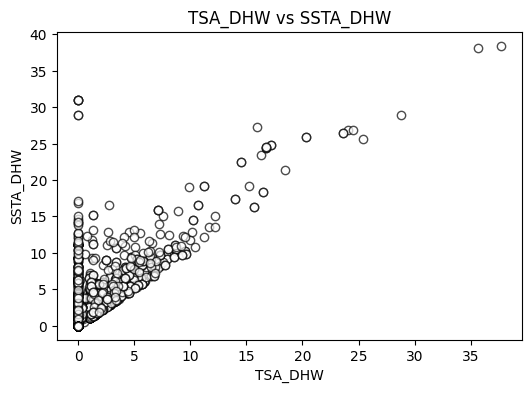

In [357]:
Plotting_feature_target(Bleaching,'TSA_DHW', 'SSTA_DHW')

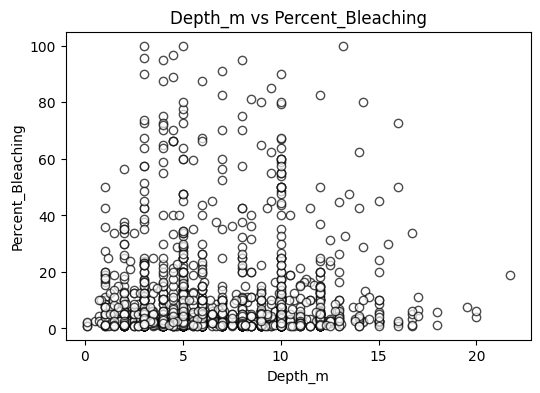

In [358]:
Plotting_feature_target(Bleaching,'Depth_m')

In [359]:
def Create_Feature_from_equetion(O1, O2,f):
    
    from scipy.stats import pearsonr, spearmanr

    transforms = {
        'feature_En is '+ f: Bleaching[f],
        'original1 is ' + O1: Bleaching[O1],
        'original2 is ' + O2: Bleaching[O2]
        
    }

    for name, col in transforms.items():
        r, _ = spearmanr(col, Bleaching['Percent_Bleaching'])
        print(f"{name}: Spearman r = {r:.4f}")
        
    print("="*50)
    
    for name, col in transforms.items():
        r, _ = pearsonr(col, Bleaching['Percent_Bleaching'])
        print(f"{name}: Pearsonr r = {r:.4f}")

In [360]:
# สร้าง interaction features ที่ make sense ทาง domain
Bleaching['SSTA_DHW_minus_Depth']    = Bleaching['SSTA_DHW']  - np.sqrt(Bleaching['Depth_m'])
Bleaching['SSTA_DHW_divide_Depth']    = Bleaching['SSTA_DHW']  / np.sqrt(Bleaching['Depth_m'])

C:\Users\superuser\AppData\Local\Temp\ipykernel_25608\1406245990.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bleaching['SSTA_DHW_minus_Depth']    = Bleaching['SSTA_DHW']  - np.sqrt(Bleaching['Depth_m'])
C:\Users\superuser\AppData\Local\Temp\ipykernel_25608\1406245990.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Bleaching['SSTA_DHW_divide_Depth']    = Bleaching['SSTA_DHW']  / np.sqrt(Bleaching['Depth_m'])


In [361]:
Create_Feature_from_equetion('SSTA_DHW','Depth_m', 'SSTA_DHW_minus_Depth')

feature_En is SSTA_DHW_minus_Depth: Spearman r = 0.1691
original1 is SSTA_DHW: Spearman r = 0.1744
original2 is Depth_m: Spearman r = -0.0193
feature_En is SSTA_DHW_minus_Depth: Pearsonr r = 0.2450
original1 is SSTA_DHW: Pearsonr r = 0.2526
original2 is Depth_m: Pearsonr r = 0.0092


##

##

##

==================================================
# Stage 1: Classification model
==================================================

In [362]:
df_model = df_Clean_already.copy()

# 1. สร้างคอลัมน์ 'Bin' เพื่อช่วยในการแบ่ง (Stratification)
# แบ่งเป็น 0 (ไม่ฟอก) กับ 1 (ฟอกขาว)
df_model['Classify'] = (df_model['Percent_Bleaching'] >= 1).astype(int)
print(df_exploratory[['Classify']].value_counts())
print('='*40)
print(f"Original feature : {len(df_Clean_already.columns)} ---> become {len(df_model.columns)}")

Classify
0           4513
1           1599
Name: count, dtype: int64
Original feature : 37 ---> become 38


In [363]:
def feature_importance(model, feature_train):
    importances = model.feature_importances_
    feature_names = feature_train.columns
   
    df_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    print(f"Columns have all : {len(df_importance)}")
    
    return df_importance.round(2)


df_requirementpaper = ['SSTA', 'Latitude_Degrees', 'Longitude_Degrees', 'Depth_m', 'ClimSST']
df_additiveexperiment = ['SSTA_DHW', 'Year', 'Temperature_Kelvin']
feature_paperClassify = df_model[df_requirementpaper]
feature_additiveClassify = df_model[df_additiveexperiment]
target_Classify = df_model['Classify']

#==================================================================
X_trainpaper , X_testpaper , X_trainadd , X_testadd , y_train_Class , y_test_Class = train_test_split(feature_paperClassify.values, feature_additiveClassify.values, target_Classify.values , test_size=0.2 , random_state=42)

X_trainpaper.shape , X_testpaper.shape , X_trainadd.shape , X_testadd.shape , y_train_Class.shape , y_test_Class.shape


((4889, 5), (1223, 5), (4889, 3), (1223, 3), (4889,), (1223,))

In [364]:
X_train_Classify_together = np.concatenate([X_trainpaper, X_trainadd], axis=1)
X_test_Classify_together = np.concatenate([X_testpaper, X_testadd], axis=1)

In [365]:
X_train_Classify_together.shape , X_test_Classify_together.shape

((4889, 8), (1223, 8))

In [366]:
def Classification_model(X_train, y_train, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    oof_preds = np.zeros(len(X_train))  # Out-of-fold predictions
    models = []
    auc_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        print(f"\n===== Fold {fold + 1} / {n_splits} =====")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        clf = lgb.LGBMClassifier(
            class_weight='balanced',
            n_estimators=1000,
            learning_rate=0.05,
            max_depth=6,
            random_state=42
        )

        fit_params = {
            'callbacks': [lgb.early_stopping(100), lgb.log_evaluation(10)],
            'eval_metric': 'auc',
            'eval_set': [(X_val, y_val)],
        }

        clf.fit(X_tr, y_tr, **fit_params)

        # เก็บ OOF predictions
        oof_preds[val_idx] = clf.predict_proba(X_val)[:, 1]
        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        auc_scores.append(fold_auc)
        models.append(clf)

        print(f"Fold {fold + 1} AUC: {fold_auc:.4f}")

    oof_auc = roc_auc_score(y_train, oof_preds)
    print(f"\nOOF AUC: {oof_auc:.4f}")
    print(f"Mean CV AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

    return models, oof_preds, auc_scores , clf


# เรียกใช้
models, oof_preds, auc_scores, clf = Classification_model(X_train_Classify_together, y_train_Class, n_splits=5)


===== Fold 1 / 5 =====
[LightGBM] [Info] Number of positive: 1013, number of negative: 2898
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1638
[LightGBM] [Info] Number of data points in the train set: 3911, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds
[10]	valid_0's auc: 0.711516	valid_0's binary_logloss: 0.643284
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[20]	valid_0's auc: 0.731919	valid_0's binary_logloss: 0.608078
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[410]	valid_0's auc: 0.831655	valid_0's binary_logloss: 0.448644
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[320]	valid_0's auc: 0.821308	valid_0's binary_logloss: 0.47447
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[290]	valid_0's auc: 0.850522	valid_0's binary_logloss: 0.444266
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [367]:
def predict_ensemble(models, X_test):
    preds = np.mean([m.predict_proba(X_test)[:, 1] for m in models], axis=0)
    pred_labels = (preds >= 0.5).astype(int)
    
    result_df = pd.DataFrame({
        'prob_class_1': preds,
        'predicted_label': pred_labels
    })
    
    return result_df

result_df = predict_ensemble(models, X_test_Classify_together)
result_df

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMCla

,prob_class_1,predicted_label
0,0.542442,1
1,0.909656,1
2,0.098030,0
3,0.461983,0
4,0.110856,0
...,...,...
1218,0.257600,0
1219,0.609218,1
1220,0.815882,1
1221,0.075943,0


In [368]:
def predict_ensemble(models, X_test):
    fold_preds = np.array([m.predict_proba(X_test)[:, 1] for m in models])
    
    result_df = pd.DataFrame(
        fold_preds.T, 
        columns=[f'prob_fold_{i+1}' for i in range(len(models))]
    )
    
    result_df['prob_mean'] = fold_preds.mean(axis=0)
    result_df['predicted_label'] = (result_df['prob_mean'] >= 0.5).astype(int)
    
    return result_df

result_df = predict_ensemble(models, X_test_Classify_together)
result_df

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMCla

,prob_fold_1,prob_fold_2,prob_fold_3,prob_fold_4,prob_fold_5,prob_mean,predicted_label
0,0.634290,0.676086,0.695421,0.438404,0.268012,0.542442,1
1,0.947413,0.931259,0.861944,0.904447,0.903216,0.909656,1
2,0.141841,0.120827,0.035600,0.100116,0.091768,0.098030,0
3,0.395168,0.573046,0.271112,0.462441,0.608150,0.461983,0
4,0.123660,0.064253,0.128318,0.151074,0.086977,0.110856,0
...,...,...,...,...,...,...,...
1218,0.392455,0.108045,0.168747,0.261550,0.357204,0.257600,0
1219,0.713915,0.669093,0.558717,0.727662,0.376704,0.609218,1
1220,0.770300,0.844060,0.836179,0.750423,0.878447,0.815882,1
1221,0.029264,0.055696,0.069668,0.179556,0.045533,0.075943,0


c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold: 0.45


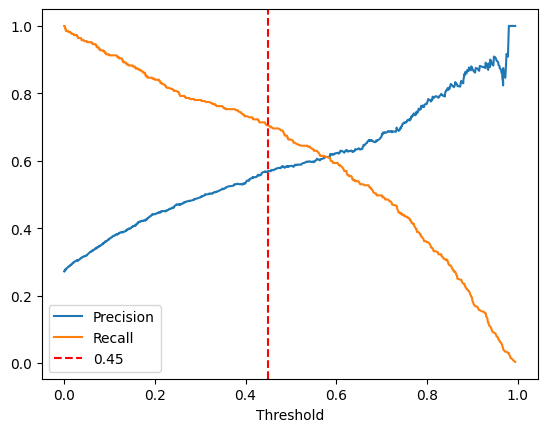

In [369]:
# หา best threshold

from sklearn.metrics import precision_recall_curve

y_prob = clf.predict_proba(X_test_Classify_together)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_test_Class, y_prob >= t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.2f}")


#============================================================================

precision, recall, thresholds = precision_recall_curve(y_test_Class, y_prob)

# plot ดู
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=best_threshold.round(2))
plt.xlabel('Threshold')
plt.legend()
plt.show()

In [370]:
clf.__dict__

{'boosting_type': 'gbdt',
 'objective': None,
 'num_leaves': 31,
 'max_depth': 6,
 'learning_rate': 0.05,
 'n_estimators': 1000,
 'subsample_for_bin': 200000,
 'min_split_gain': 0.0,
 'min_child_weight': 0.001,
 'min_child_samples': 20,
 'subsample': 1.0,
 'subsample_freq': 0,
 'colsample_bytree': 1.0,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'random_state': 42,
 'n_jobs': None,
 'importance_type': 'split',
 '_Booster': <lightgbm.basic.Booster at 0x25207db6a50>,
 '_evals_result': {'valid_0': OrderedDict([('auc',
                [0.7151966457755552,
                 0.7406999978162602,
                 0.7357865831022209,
                 0.7348311969078244,
                 0.7378775140305287,
                 0.7375117376018169,
                 0.7411831502631406,
                 0.7513593780708842,
                 0.7609487257877842,
                 0.7627557705326141,
                 0.7662661323783111,
                 0.7672187888978664,
                 0.7678793702094207,
  

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='binary_logloss'>

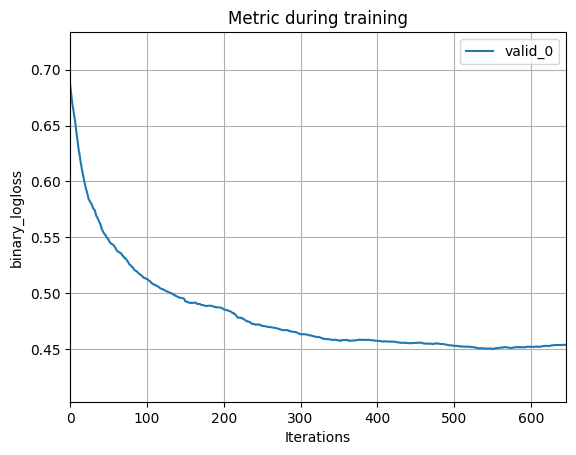

In [371]:
lgb.plot_metric(clf, metric='binary_logloss')

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='auc'>

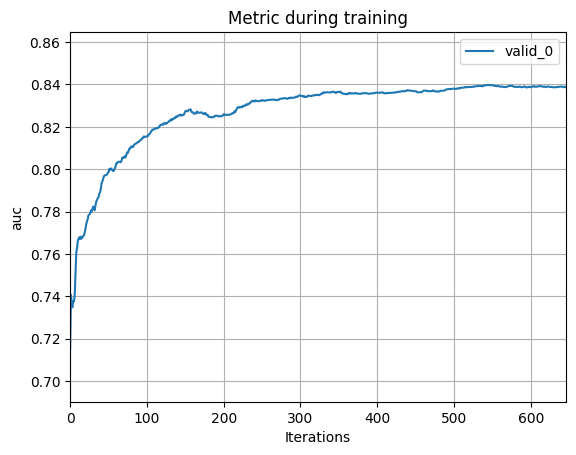

In [372]:
lgb.plot_metric(clf, metric='auc')

In [373]:
clf.score(X_train_Classify_together, y_train_Class) # Accuracy training Classification

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9130701574964205

In [374]:
clf.score(X_test_Classify_together, y_test_Class) # Accuracy testing Classification

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.7808667211774325

In [375]:
clf.predict(X_test_Classify_together)[:20]

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0])

In [376]:
clf.predict_proba(X_test_Classify_together)[:20]

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[0.73198839, 0.26801161],
       [0.09678385, 0.90321615],
       [0.90823225, 0.09176775],
       [0.39184998, 0.60815002],
       [0.91302287, 0.08697713],
       [0.91671508, 0.08328492],
       [0.95137288, 0.04862712],
       [0.78819577, 0.21180423],
       [0.85018524, 0.14981476],
       [0.27649236, 0.72350764],
       [0.99539976, 0.00460024],
       [0.22187098, 0.77812902],
       [0.3581774 , 0.6418226 ],
       [0.50762261, 0.49237739],
       [0.25995999, 0.74004001],
       [0.18775174, 0.81224826],
       [0.91800487, 0.08199513],
       [0.51276924, 0.48723076],
       [0.94601172, 0.05398828],
       [0.71742681, 0.28257319]])

## **confusion matrix**
$$
\begin{bmatrix}
C_{0,0} & C_{0,1} \\
C_{1,0} & C_{1,1}
\end{bmatrix}
=
\begin{bmatrix}
tn & fp \\
fn & tp
\end{bmatrix}
$$


In [377]:
con_matrix = confusion_matrix(y_test_Class, clf.predict(X_test_Classify_together))
con_matrix

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([[735, 156],
       [112, 220]], dtype=int64)

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ALL train data : 1223
y_test_Classify
0                  891
1                  332
Name: count, dtype: int64


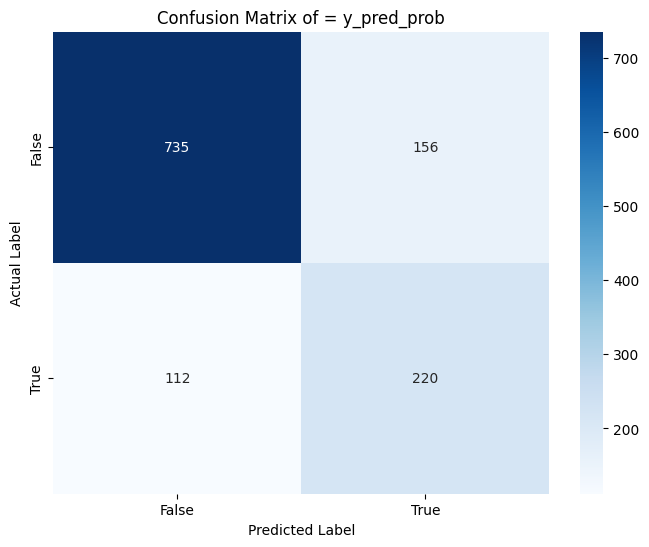

In [378]:
def plot_confusion_matrix(y_true, y_pred, classes, name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix of = {name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return cm
    
print(f"ALL train data : {len(y_test_Class)}")
print(f"{pd.DataFrame(y_test_Class, columns=['y_test_Classify']).value_counts()}")
corr_matrix = plot_confusion_matrix(y_test_Class, clf.predict(X_test_Classify_together), ['False','True'], 'y_pred_prob')

In [379]:
print(classification_report(y_train_Class, clf.predict(X_train_Classify_together))) # Classification training data

              precision    recall  f1-score   support

           0       0.97      0.91      0.94      3622
           1       0.78      0.93      0.85      1267

    accuracy                           0.91      4889
   macro avg       0.88      0.92      0.89      4889
weighted avg       0.92      0.91      0.92      4889



c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [380]:
print(classification_report(y_test_Class, clf.predict(X_test_Classify_together))) # Classification testing data

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.87      0.82      0.85       891
           1       0.59      0.66      0.62       332

    accuracy                           0.78      1223
   macro avg       0.73      0.74      0.73      1223
weighted avg       0.79      0.78      0.78      1223



##

### ***y probability***

In [381]:
y_prob = clf.predict_proba(X_test_Classify_together)[:, 1]
y_prob_adjust = (y_prob >= 0.33).astype(int)

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [382]:
print(classification_report(y_test_Class, y_prob_adjust))

              precision    recall  f1-score   support

           0       0.89      0.72      0.80       891
           1       0.51      0.77      0.61       332

    accuracy                           0.73      1223
   macro avg       0.70      0.74      0.70      1223
weighted avg       0.79      0.73      0.75      1223



ALL train data : 1223
y_test_Classify
0                  891
1                  332
Name: count, dtype: int64


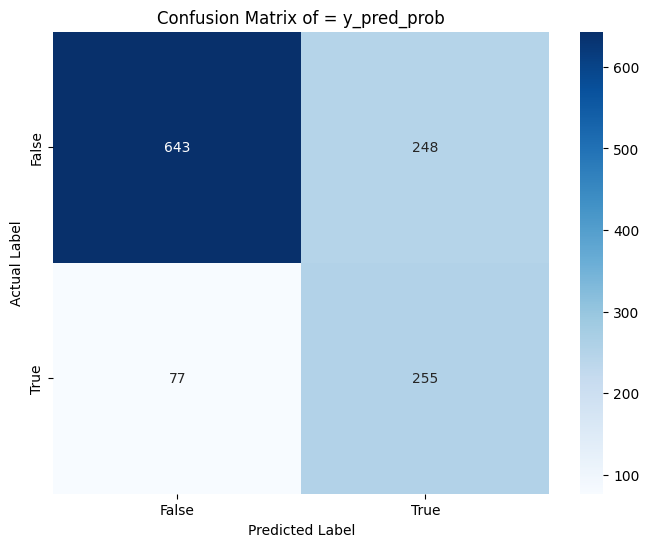

In [383]:
print(f"ALL train data : {len(y_test_Class)}")
print(f"{pd.DataFrame(y_test_Class, columns=['y_test_Classify']).value_counts()}")
corr_matrix = plot_confusion_matrix(y_test_Class, y_prob_adjust, ['False','True'], 'y_pred_prob')

In [384]:
feature_together = pd.concat([feature_paperClassify, feature_additiveClassify], axis=1)

In [385]:
feature_importance(clf, feature_together)

Columns have all : 8


,feature,importance
7,Temperature_Kelvin,1803
0,SSTA,1746
1,Latitude_Degrees,1599
2,Longitude_Degrees,1585
4,ClimSST,1516
5,SSTA_DHW,1370
3,Depth_m,1300
6,Year,1094


In [386]:
Keep_feature = clf.predict_proba(X_test_Classify_together)[:, 1]

# สร้าง mask ด้วย threshold ที่เลือก
mask_test = Keep_feature >= 0.3  # True/False array
mask_test

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([False,  True, False, ...,  True, False,  True])

In [387]:
# กรอง features สำหรับ Stage 2
X_test_reg_allmodel = X_test_Classify_together[mask_test]
y_test_reg_allmodel = y_test_Class[mask_test]

# เช็คว่า ground truth จริงๆ มีสัดส่วนเท่าไหร่
print(f"มี bleaching จริง: {(y_test_Class > 0).sum()} ({(y_test_Class > 0).mean()*100:.1f}%)")
print(f"ไม่มี bleaching จริง: {(y_test_Class == 0).sum()} ({(y_test_Class == 0).mean()*100:.1f}%)")
print("="* 30)
print(f"ทั้งหมด: {len(mask_test)}")
print(f"ส่งไป Stage 2: {mask_test.sum()}  ({mask_test.mean()*100:.1f}%)")
print(f"predict เป็น 0: {(~mask_test).sum()}  ({(~mask_test).mean()*100:.1f}%)")

มี bleaching จริง: 332 (27.1%)
ไม่มี bleaching จริง: 891 (72.9%)
ทั้งหมด: 1223
ส่งไป Stage 2: 527  (43.1%)
predict เป็น 0: 696  (56.9%)


##

In [388]:
from sklearn.tree import DecisionTreeClassifier

def find_best_split(X, y):
    split_info = {}
    for col in X.columns:
        dt = DecisionTreeClassifier(max_depth=1, criterion='entropy')
        dt.fit(X[[col]], y)
        
        tree = dt.tree_
        
        # Information Gain = impurity(root) - weighted avg impurity(children)
        root_impurity = tree.impurity[0]
        n_total = tree.n_node_samples[0]
        
        left_impurity  = tree.impurity[1]
        right_impurity = tree.impurity[2]
        n_left  = tree.n_node_samples[1]
        n_right = tree.n_node_samples[2]
        
        weighted_child_impurity = (n_left/n_total) * left_impurity + \
                                  (n_right/n_total) * right_impurity
        
        information_gain = root_impurity - weighted_child_impurity
        threshold = tree.threshold[0]
        
        split_info[col] = {
            'threshold': threshold,
            'information_gain': information_gain,
            'root_impurity': root_impurity
        }
    
    result = pd.DataFrame(split_info).T
    result = result.sort_values('information_gain', ascending=False)
    return result

split_df = find_best_split(feature_together, target_Classify)
split_df

,threshold,information_gain,root_impurity
Latitude_Degrees,22.288292,0.017962,0.829176
Longitude_Degrees,-32.443611,0.013079,0.829176
Year,2012.500000,0.005343,0.829176
SSTA_DHW,11.030000,0.004918,0.829176
Depth_m,11.100000,0.003945,0.829176
ClimSST,291.320007,0.003534,0.829176
Temperature_Kelvin,298.165009,0.002094,0.829176
SSTA,0.801250,0.001397,0.829176


In [389]:
important_features = feature_importance(clf, feature_together)

Columns have all : 8


In [390]:
important_features

,feature,importance
7,Temperature_Kelvin,1803
0,SSTA,1746
1,Latitude_Degrees,1599
2,Longitude_Degrees,1585
4,ClimSST,1516
5,SSTA_DHW,1370
3,Depth_m,1300
6,Year,1094


In [391]:
# สมมติว่า importance_df คือ DataFrame ข้างบน
importance_df = important_features.set_index('feature')

# Merge กับ split_df (IG)
combined_df = split_df[['threshold', 'information_gain']].join(importance_df)
combined_df = combined_df.sort_values('importance', ascending=False)
combined_df

,threshold,information_gain,importance
Temperature_Kelvin,298.165009,0.002094,1803
SSTA,0.801250,0.001397,1746
Latitude_Degrees,22.288292,0.017962,1599
Longitude_Degrees,-32.443611,0.013079,1585
ClimSST,291.320007,0.003534,1516
SSTA_DHW,11.030000,0.004918,1370
Depth_m,11.100000,0.003945,1300
Year,2012.500000,0.005343,1094


C:\Users\superuser\AppData\Local\Temp\ipykernel_25608\2943941925.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([


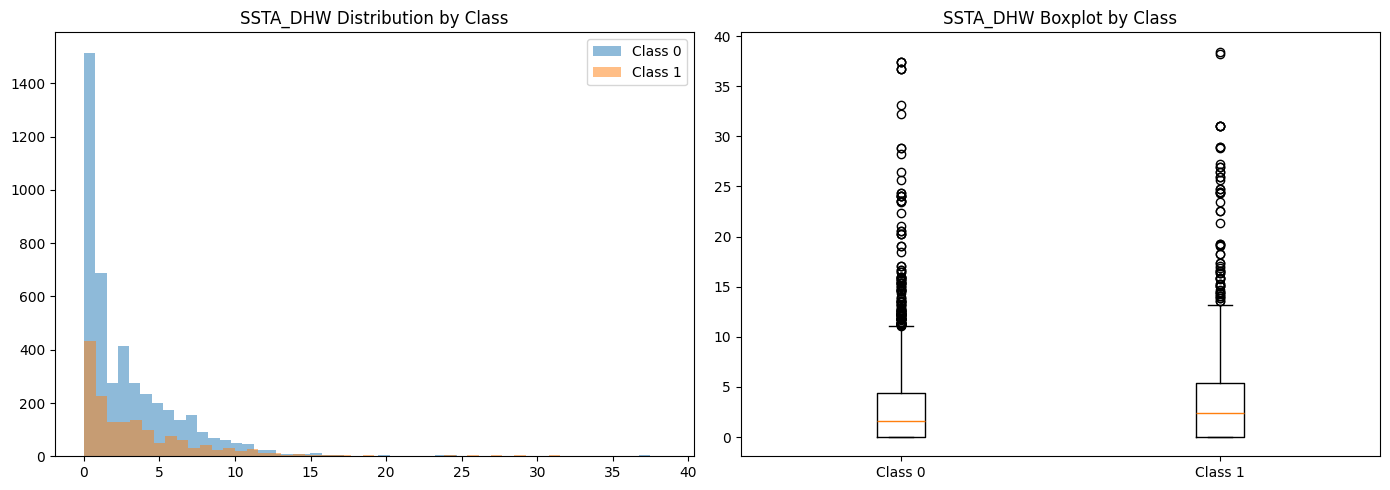

           count      mean       std  min  25%   50%    75%    max
Classify                                                          
0         4513.0  2.936852  3.771436  0.0  0.0  1.61  4.425  37.45
1         1599.0  3.763181  4.803445  0.0  0.0  2.39  5.360  38.45


In [392]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. ดู Distribution ของ SSTA_DHW แยกตาม class
for label, group in feature_together.groupby(target_Classify):
    axes[0].hist(group['SSTA_DHW'], bins=50, alpha=0.5, label=f'Class {label}')
axes[0].set_title('SSTA_DHW Distribution by Class')
axes[0].legend()

# 2. ดู outliers
axes[1].boxplot([
    feature_together[target_Classify == 0]['SSTA_DHW'],
    feature_together[target_Classify == 1]['SSTA_DHW']
], labels=['Class 0', 'Class 1'])
axes[1].set_title('SSTA_DHW Boxplot by Class')

plt.tight_layout()
plt.show()

# 3. ดู stats แยก class
print(feature_together.groupby(target_Classify)['SSTA_DHW'].describe())

In [393]:
feature_together

,SSTA,Latitude_Degrees,Longitude_Degrees,Depth_m,ClimSST,SSTA_DHW,Year,Temperature_Kelvin
0,1.320000,-20.899833,149.407722,4.0,297.78,3.960000,2016,301.670
1,1.320000,-20.893056,149.421000,5.0,297.78,3.960000,2016,301.670
2,0.870000,-20.745806,149.472056,6.0,298.17,2.680000,2016,301.380
3,1.070000,-20.737694,149.464944,5.0,298.21,3.650000,2016,301.560
4,1.760000,-20.259361,148.814583,2.0,296.48,3.840000,2017,296.380
...,...,...,...,...,...,...,...,...
9641,0.033333,20.738889,107.058333,3.2,262.15,2.378333,2003,302.955
9646,0.510000,20.845833,107.177778,3.0,299.80,0.000000,2003,302.300
9649,0.050000,12.601722,53.817306,6.0,301.40,0.000000,2008,302.670
9663,0.110000,15.701611,42.391806,9.0,304.39,2.250000,2008,303.890


In [394]:
# 2. Spatial feature (ทั้ง IG และ LGB สูง)
feature_together['SSTA_DHW_divide_Depth'] = feature_together['SSTA_DHW'] / np.sqrt(feature_together['Depth_m'])

# 4. ตรวจ IG ใหม่
split_df_new = find_best_split(feature_together, target_Classify)
split_df_new.sort_values('information_gain', ascending=False).head(10)

,threshold,information_gain,root_impurity
Latitude_Degrees,22.288292,0.017962,0.829176
Longitude_Degrees,-32.443611,0.013079,0.829176
SSTA_DHW_divide_Depth,4.911191,0.007104,0.829176
Year,2012.500000,0.005343,0.829176
SSTA_DHW,11.030000,0.004918,0.829176
Depth_m,11.100000,0.003945,0.829176
ClimSST,291.320007,0.003534,0.829176
Temperature_Kelvin,298.165009,0.002094,0.829176
SSTA,0.801250,0.001397,0.829176


In [395]:
feature_Engineering_model = feature_together.copy()

feature_Engineering_model = feature_Engineering_model.drop(columns=['Depth_m'], axis=1)

In [396]:
feature_Engineering_model

,SSTA,Latitude_Degrees,Longitude_Degrees,Depth_m,ClimSST,SSTA_DHW,Year,Temperature_Kelvin,SSTA_DHW_divide_Depth
0,1.320000,-20.899833,149.407722,4.0,297.78,3.960000,2016,301.670,1.980000
1,1.320000,-20.893056,149.421000,5.0,297.78,3.960000,2016,301.670,1.770966
2,0.870000,-20.745806,149.472056,6.0,298.17,2.680000,2016,301.380,1.094105
3,1.070000,-20.737694,149.464944,5.0,298.21,3.650000,2016,301.560,1.632330
4,1.760000,-20.259361,148.814583,2.0,296.48,3.840000,2017,296.380,2.715290
...,...,...,...,...,...,...,...,...,...
9641,0.033333,20.738889,107.058333,3.2,262.15,2.378333,2003,302.955,1.329529
9646,0.510000,20.845833,107.177778,3.0,299.80,0.000000,2003,302.300,0.000000
9649,0.050000,12.601722,53.817306,6.0,301.40,0.000000,2008,302.670,0.000000
9663,0.110000,15.701611,42.391806,9.0,304.39,2.250000,2008,303.890,0.750000


In [397]:
X_trainEn_Clssify , X_testEn_Classify , y_trainEn_Classify , y_testEn_Classify = train_test_split(feature_Engineering_model.values, target_Classify.values, test_size=0.2 , random_state=42)
X_trainEn_Clssify.shape , X_testEn_Classify.shape , y_trainEn_Classify.shape , y_testEn_Classify.shape

((4889, 9), (1223, 9), (4889,), (1223,))

In [398]:
modelsEn, oof_predsEn, auc_scoresEn, clfEn = Classification_model(X_trainEn_Clssify, y_trainEn_Classify, n_splits=5)


===== Fold 1 / 5 =====
[LightGBM] [Info] Number of positive: 1013, number of negative: 2898
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1893
[LightGBM] [Info] Number of data points in the train set: 3911, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[10]	valid_0's auc: 0.719252	valid_0's binary_logloss: 0.639588
[LightGBM] [Warning] No further splits with positive gain, bes

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[250]	valid_0's auc: 0.820132	valid_0's binary_logloss: 0.474076
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[480]	valid_0's auc: 0.81765	valid_0's binary_logloss: 0.477441
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[490]	valid_0's auc: 0.817743	valid_0's binary_logloss: 0.478055
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Fold 4 AUC: 0.8473

===== Fold 5 / 5 =====
[LightGBM] [Info] Number of positive: 1014, number of negative: 2898
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1896
[LightGBM] [Info] Number of data points in the train set: 3912, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[10]	valid_0's auc: 0.761896	val

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[180]	valid_0's auc: 0.825173	valid_0's binary_logloss: 0.490379
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ALL train data : 1223
y_test_Classify
0                  891
1                  332
Name: count, dtype: int64


c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


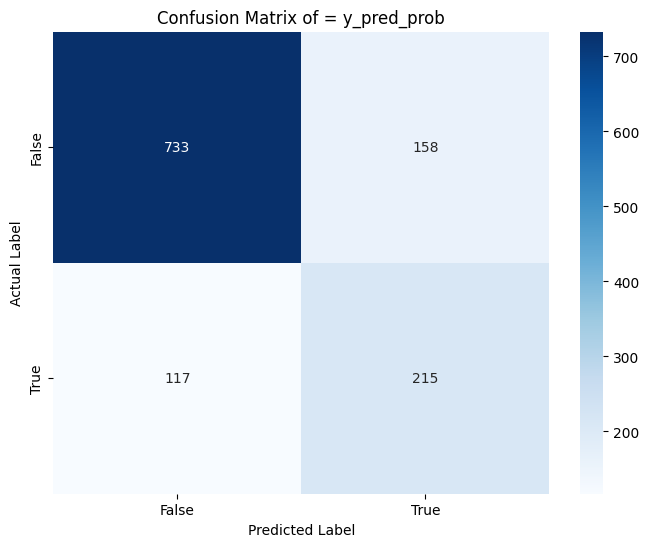

In [399]:
def plot_confusion_matrix(y_true, y_pred, classes, name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix of = {name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return cm
    
print(f"ALL train data : {len(y_testEn_Classify)}")
print(f"{pd.DataFrame(y_testEn_Classify, columns=['y_test_Classify']).value_counts()}")
corr_matrix = plot_confusion_matrix(y_testEn_Classify, clfEn.predict(X_testEn_Classify), ['False','True'], 'y_pred_prob')

In [400]:
feature_importance(clfEn, feature_Engineering_model)

Columns have all : 9


,feature,importance
7,Temperature_Kelvin,1759
0,SSTA,1687
2,Longitude_Degrees,1627
1,Latitude_Degrees,1626
4,ClimSST,1598
8,SSTA_DHW_divide_Depth,1107
5,SSTA_DHW,1096
6,Year,1069
3,Depth_m,1045


In [401]:
clfEn.score(X_trainEn_Clssify, y_trainEn_Classify) # Accuracy training Classification

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.919001840867253

In [402]:
clfEn.score(X_testEn_Classify, y_testEn_Classify) # Accuracy testing Classification

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.7751430907604252

In [403]:
print(classification_report(y_testEn_Classify, clfEn.predict(X_testEn_Classify))) # Classification testing data

              precision    recall  f1-score   support

           0       0.86      0.82      0.84       891
           1       0.58      0.65      0.61       332

    accuracy                           0.78      1223
   macro avg       0.72      0.74      0.73      1223
weighted avg       0.78      0.78      0.78      1223



c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Best threshold: 0.35


c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


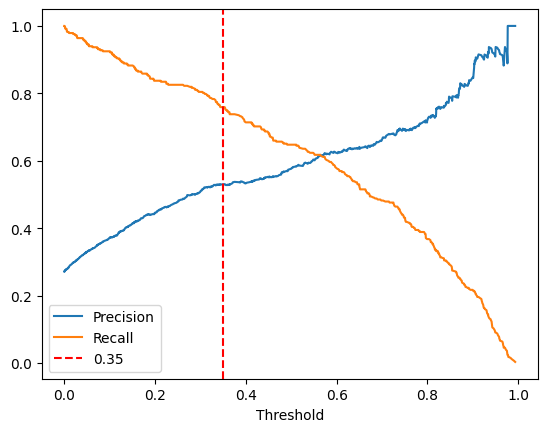

In [404]:
# หา best threshold
y_probEn = clfEn.predict_proba(X_testEn_Classify)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = [f1_score(y_testEn_Classify, y_probEn >= t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.2f}")


#============================================================================

precision, recall, thresholds = precision_recall_curve(y_testEn_Classify, y_probEn)

# plot ดู
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=best_threshold.round(2))
plt.xlabel('Threshold')
plt.legend()
plt.show()

ALL train data : 1223
y_test_Classify
0                  891
1                  332
Name: count, dtype: int64


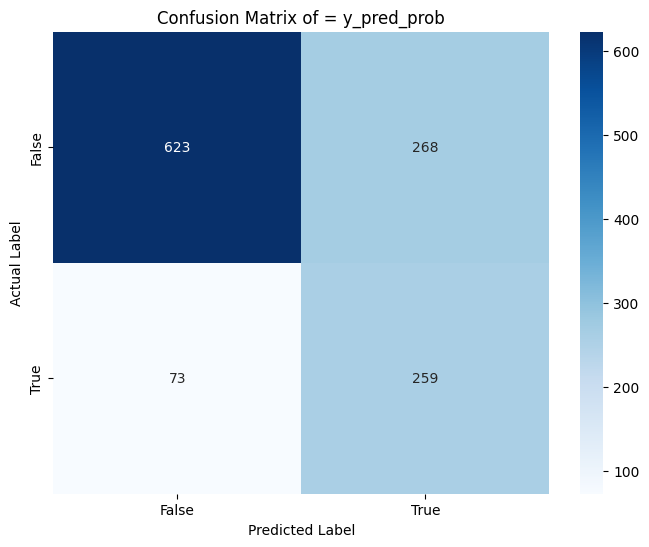

In [405]:
y_prob_adjustEn = (y_prob >= 0.3).astype(int)

print(f"ALL train data : {len(y_testEn_Classify)}")
print(f"{pd.DataFrame(y_testEn_Classify, columns=['y_test_Classify']).value_counts()}")
corr_matrix = plot_confusion_matrix(y_testEn_Classify, y_prob_adjustEn, ['False','True'], 'y_pred_prob')

In [406]:
Keep_featureEn = clfEn.predict_proba(X_testEn_Classify)[:, 1]

# สร้าง mask ด้วย threshold ที่เลือก
mask_test_En = Keep_featureEn >= 0.3  # True/False array
mask_test_En

c:\Anaconda\Anaconda3\envs\research_env_v2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([ True,  True, False, ...,  True, False,  True])

In [407]:
# กรอง features สำหรับ Stage 2
X_test_reg_allmodel_En = X_testEn_Classify[mask_test_En]
y_test_reg_allmodel_En = y_testEn_Classify[mask_test_En]

# เช็คว่า ground truth จริงๆ มีสัดส่วนเท่าไหร่
print(f"มี bleaching จริง: {(y_testEn_Classify > 0).sum()} ({(y_testEn_Classify > 0).mean()*100:.1f}%)")
print(f"ไม่มี bleaching จริง: {(y_testEn_Classify == 0).sum()} ({(y_testEn_Classify == 0).mean()*100:.1f}%)")
print("="* 30)
print(f"ทั้งหมด: {len(mask_test_En)}")
print(f"ส่งไป Stage 2: {mask_test_En.sum()}  ({mask_test_En.mean()*100:.1f}%)")
print(f"predict เป็น 0: {(~mask_test_En).sum()}  ({(~mask_test_En).mean()*100:.1f}%)")

มี bleaching จริง: 332 (27.1%)
ไม่มี bleaching จริง: 891 (72.9%)
ทั้งหมด: 1223
ส่งไป Stage 2: 524  (42.8%)
predict เป็น 0: 699  (57.2%)


In [408]:
X_testEn_Classify.shape

(1223, 9)

In [409]:
X_test_reg_allmodel_En.shape

(524, 9)

In [410]:
X_test_reg_allmodel_En

array([[ 3.30000000e-01,  8.91666670e-02,  1.19616583e+02, ...,
         2.00300000e+03,  3.02620000e+02,  0.00000000e+00],
       [ 1.20000000e-01,  1.83283333e+01, -6.88180556e+01, ...,
         2.00600000e+03,  3.01630000e+02,  1.18068130e+00],
       [ 5.80000000e-01,  2.12688889e+01, -1.57824111e+02, ...,
         2.00800000e+03,  2.97730000e+02,  0.00000000e+00],
       ...,
       [ 6.00000000e-01,  1.83422500e+01, -7.83555833e+01, ...,
         2.01100000e+03,  3.03450000e+02,  4.12604440e-01],
       [ 9.80000000e-01,  1.87716667e+01, -6.48780000e+01, ...,
         2.00600000e+03,  3.01110000e+02,  9.23760431e-01],
       [ 1.00000000e-01, -1.60060000e+01,  1.45848667e+02, ...,
         2.00700000e+03,  3.00910000e+02,  2.14402425e+00]])